In [1]:
from nilearn import plotting
from nilearn.plotting import cm
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torchio as tio
from pathlib import Path
import napari

In [2]:
#Defining where our data is stored
datadir = Path("/home/caleb/UCSF-PDGM-v5")

#building the arrays of mri's and tumor masks (sorted)
def build_dataset(datadir):

    image_paths = sorted(datadir.rglob("*T1_bias.nii.gz"))
    label_paths = sorted(datadir.rglob("*tumor_segmentation.nii.gz"))
    assert len(image_paths) == len(label_paths), "Number of images and labels do not match!"
    return image_paths, label_paths
    




In [3]:
#combine the mri's and masks into tio subjects
def build_subjects(image_paths, label_paths):
    subjects = []
    for (image_path, label_path) in zip(image_paths, label_paths):
        subject = tio.Subject(
            mri=tio.ScalarImage(image_path),
            seg=tio.LabelMap(label_path),
        )
        subjects.append(subject)
    return subjects

In [14]:
from torch.utils.data import random_split
#take our paired subjects and create patches i.e. small chunks of the image and mask for training

def binarize_label(x):
    return (x > 0).float()


def build_patches(subjects, patch_size=64,patch_overlap=32):
    
    len_sub = len(subjects)

    train_len = int(0.9 * len_sub)
    val_len = len_sub - train_len
    lengths = [train_len, val_len]

    train_set, val_set = random_split(subjects, lengths)
    
    #normalize our data between 0 and one

    transform = tio.Compose([
        tio.RescaleIntensity(out_min_max=(0, 1)),
        tio.Lambda(binarize_label, types_to_apply=tio.LABEL),
    ])

    train_dataset = tio.SubjectsDataset(train_set,transform=transform)
    val_dataset = tio.SubjectsDataset(val_set,transform=transform)

    #define our sampler
    sampler = tio.LabelSampler(patch_size = patch_size,label_name='seg', label_probabilities={0:0.05, 1:.95})
    
    train_queue = tio.Queue(
        subjects_dataset=train_dataset,
        max_length=300,        
        samples_per_volume=4,  
        sampler=sampler,
        num_workers=4,
        shuffle_subjects=True,
        shuffle_patches=True
    )

    val_queue = tio.Queue(
        subjects_dataset=val_dataset,
        max_length=300,
        samples_per_volume=8, # Take 8 patches per validation subject
        sampler=sampler,
        num_workers=4
    )
    
    return train_queue, val_queue

In [15]:
#define network
import snntorch as snn
from snntorch import utils, surrogate

class SpikingUnet(nn.Module):

    def __init__(self, in_channels ,out_chanels=2, beta=0.9):
        # layer parameters
        super().__init__()
        
        spike_grad = surrogate.fast_sigmoid()

        #encode l1

        self.enc1 = SNNConvBlock(in_channels, 16, beta, spike_grad)
        self.pool1 = nn.MaxPool3d(2)

        #encode l2
        self.enc2 = SNNConvBlock(16, 32, beta,spike_grad)
        self.pool2 = nn.MaxPool3d(2)

        #encode l3
        self.enc3 = SNNConvBlock(32, 64, beta, spike_grad)
        self.pool3 = nn.MaxPool3d(2)


        #bridge layer (bottom of the network)

        self.bridge = SNNConvBlock(64,128, beta, spike_grad)

        #decode l1
        self.up1 = nn.ConvTranspose3d(128, 64, kernel_size=2, stride=2)
        self.dec1 = SNNConvBlock(128, 64, beta, spike_grad)

        #decode l2
        self.up2 = nn.ConvTranspose3d(64, 32, kernel_size=2, stride=2)
        self.dec2 = SNNConvBlock(64, 32, beta, spike_grad)

        #decode l3
    
        self.up3 = nn.ConvTranspose3d(32, 16, kernel_size=2, stride=2)
        self.dec3 = SNNConvBlock(32,16, beta, spike_grad)

        #output layer
        self.output_conv = nn.Conv3d(16,out_chanels, kernel_size=1)
        self.output_leaky = snn.Leaky(beta=beta, spike_grad=spike_grad, init_hidden=True, output = True)
    
    def forward(self,x):
        #this is the feed forward
        #encoder
        e1 = self.enc1(x)
        p1 = self.pool1(e1)
        
        e2 = self.enc2(p1)
        p2 = self.pool2(e2)
        
        e3 = self.enc3(p2)
        p3 = self.pool3(e3)

        #bridge base layer
        b = self.bridge(p3)
        
        #decoder
        u1 = self.up1(b)
        cat1 = torch.cat([e3, u1], dim=1)
        d1 = self.dec1(cat1)
        
        u2 = self.up2(d1)
        cat2 = torch.cat([e2, u2], dim=1)
        d2 = self.dec2(cat2)
        
        u3 = self.up3(d2)
        cat3 = torch.cat([e1, u3], dim=1)
        d3 = self.dec3(cat3)
        
        spk, mem = self.output_leaky(self.output_conv(d3))
        return spk, mem
    
    def init_mem(self):
            utils.reset(self)


class SNNConvBlock(nn.Module):

    def __init__(self,in_channels,out_chanels, beta, spike_grad):
        
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_channels, out_chanels, kernel_size=3, padding=1),
            nn.BatchNorm3d(out_chanels),
            snn.Leaky(beta=beta, spike_grad=spike_grad, init_hidden=True),

            nn.Conv3d(out_chanels, out_chanels,kernel_size=3,padding=1),
            nn.BatchNorm3d(out_chanels),
            snn.Leaky(beta=beta,spike_grad=spike_grad, init_hidden=True)
        )

    def forward(self, x):
        return self.block(x)
        


In [16]:
image_paths, label_paths = build_dataset(datadir=datadir)
subjects = build_subjects(image_paths,label_paths)

In [17]:
from tqdm import tqdm
from snntorch import spikegen

def train(model, loader, optimizer, loss_fn, device, spike_len=10,num_epochs=10):
    model.train()
    running_loss = 0


    loop = tqdm(loader, desc="Training", leave=True)

    for i, batch in enumerate(loop):
        data = batch['mri'][tio.DATA].to(device)
        targets = batch['seg'][tio.DATA].to(device).long()#.squeeze(1)
        targets[targets > 0] = 1
        spike_train = spikegen.rate(data,num_steps=spike_len)

        model.init_mem()
        mem_rec = []

        #submits spike rate to the ff network
        for step in range(spike_len):
            spike_out, mem_out = model(spike_train[step])
            mem_rec.append(mem_out)
        
        #calculate loss by taking the membrane potentials and the average value and applying the loss fn

        mem_rec = torch.stack(mem_rec)
        logits = mem_rec.mean(dim=0)
        loss = loss_fn(logits, targets)

        #back prop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        loop.set_postfix(loss=loss.item(), avg_loss=running_loss / (i + 1))

    return running_loss / len(loader)



In [18]:
from monai.metrics import DiceMetric
from monai.utils import MetricReduction
from monai.transforms import AsDiscrete


def evaluate(model, loader, device, spike_len=10):
    model.eval()

    dice_metric = DiceMetric(include_background=False, reduction="none", get_not_nans=True)
    post_pred = AsDiscrete(argmax=True, to_onehot=2)
    post_label = AsDiscrete(to_onehot=2)

    best_sample = None
    best_dice = -1.0

    with torch.no_grad():
        for batch in tqdm(loader, desc="Eval"):
            data = batch['mri'][tio.DATA].to(device)
            targets = batch['seg'][tio.DATA].to(device).long()
            targets[targets > 0] = 1
            spike_train = spikegen.rate(data, num_steps=spike_len)

            model.init_mem()
            mem_rec = []
            for step in range(spike_len):
                _, mem_out = model(spike_train[step])
                mem_rec.append(mem_out)

            logits = torch.stack(mem_rec).mean(dim=0)
            prediction = logits.argmax(dim=1)

            val_outputs = [post_pred(i) for i in logits]
            val_label = [post_label(i.unsqueeze(0)) for i in targets]

            batch_scores = dice_metric(y_pred=val_outputs, y=val_label)
            batch_scores = batch_scores.mean(dim=1) if batch_scores.ndim > 1 else batch_scores

            for idx, dice_val in enumerate(batch_scores):
                if targets[idx, 0].sum() == 0:
                    continue  # skip patches without tumor
                dice_value = dice_val.item()
                if dice_value > best_dice:
                    best_dice = dice_value
                    best_sample = {
                        "dice": dice_value,
                        "mri": data[idx, 0].detach().cpu(),
                        "gt": targets[idx, 0].detach().cpu(),
                        "pred": prediction[idx].detach().cpu()
                    }

    scores, not_nans = dice_metric.aggregate()
    valid_scores = scores[not_nans > 0]  
    mean_dice = valid_scores.mean().item() if valid_scores.numel() > 0 else 0.0
    all_scores = valid_scores.flatten().tolist()    

    dice_metric.reset()
    print(f"\nDice score: {mean_dice:.4f}")

    return mean_dice, all_scores, best_sample

In [19]:
from torch.utils.data import DataLoader
from itertools import islice
import napari


def inspect_queue(queue, samples=1):
    viewer = napari.Viewer(ndisplay=3)
    loader = DataLoader(queue, batch_size=1, num_workers=0)
    images = []
    segs = []
    for idx, batch in enumerate(islice(loader, samples), 1):
        img = batch["mri"][tio.DATA][0, 0].numpy()
        images.append(img)
        seg = batch["seg"][tio.DATA][0, 0].numpy().astype(int)
        segs.append(seg)
        viewer.add_image(img, name=f"mri_{idx}", contrast_limits=(img.min(), img.max()))
        viewer.add_labels(seg, name=f"mask_{idx}", opacity=0.4)

    napari.run()
    return (images,segs)

train_queue, val_queue = build_patches(subjects)
ims, sgs = inspect_queue(train_queue, samples=5)

In [20]:

train_queue, val_queue = build_patches(subjects)

In [34]:
from torch.utils.data import DataLoader
from itertools import islice
import napari
def summarize_queue(queue, samples=200):
    loader = DataLoader(queue, batch_size=1, num_workers=0)
    totals = {"total": 0, "tumor_patches": 0, "empty_masks": 0}
    for batch in islice(loader, samples):
        seg = batch["seg"][tio.DATA][0, 0]
        if seg.sum() == 0:
            totals["empty_masks"] += 1
        else:
            totals["tumor_patches"] += 1
        totals["total"] += 1
    return totals

stats = summarize_queue(val_queue, samples=408)
print(stats)

{'total': 408, 'tumor_patches': 398, 'empty_masks': 10}


In [22]:
#main training area
from torch.utils.data import DataLoader
from monai.losses import DiceLoss
from monai.losses import DiceCELoss

train_queue, val_queue = build_patches(subjects)

train_loader = DataLoader(train_queue, batch_size=1)
val_loader = DataLoader(val_queue,batch_size=1)
device = torch.device("cuda") if torch.cuda.is_available() else print("CUDA ERROR WAT????")
model = SpikingUnet(in_channels=1, out_chanels=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, betas=(0.9, 0.999))
loss = DiceLoss(to_onehot_y=True, softmax=True)

#snn spike train length
spike_len = 8


In [ ]:
val_loader = DataLoader(val_queue, batch_size=1, num_workers=0)

batch = next(iter(val_loader))
shape = batch['mri'][tio.DATA].shape
if shape[-1 == 64]:
    print("good")
else:
    print("bad")

good


In [24]:
num_epochs = 5
spike_len = 8
best_dice = 0.0

train_loss_his = []

val_dice_his = []
ckpt_dir = Path("checkpoints")
ckpt_dir.mkdir(exist_ok=True)

for epoch in range(num_epochs):
    print(f"\n Epoch {epoch+1}/{num_epochs}")
    epoch_loss = train(model, train_loader, optimizer, loss, device, spike_len=spike_len)
    train_loss_his.append(epoch_loss)
    
    metrics = evaluate(model, val_loader, device, spike_len=spike_len)
    if metrics[0] > best_dice:
        best_dice = metrics[0]
        torch.save(
            {
                "epoch": epoch + 1,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "best_dice": best_dice,
            },
            ckpt_dir / "spiking_unet_best.pt",
        )
    



 Epoch 1/5


Eval: 100%|██████████| 408/408 [00:25<00:00, 15.89it/s]



Dice score: 0.4754

 Epoch 2/5


Eval: 100%|██████████| 408/408 [00:25<00:00, 15.87it/s]



Dice score: 0.4802

 Epoch 3/5


...


Dice score: 0.4012

 Epoch 4/5


Eval: 100%|██████████| 408/408 [00:25<00:00, 16.07it/s]



Dice score: 0.4480

 Epoch 5/5


Eval: 100%|██████████| 408/408 [00:26<00:00, 15.64it/s]


Dice score: 0.5309


In [25]:
metrics = evaluate(model, val_loader, device, spike_len=spike_len)

Eval: 100%|██████████| 408/408 [00:25<00:00, 16.13it/s]


Dice score: 0.5158


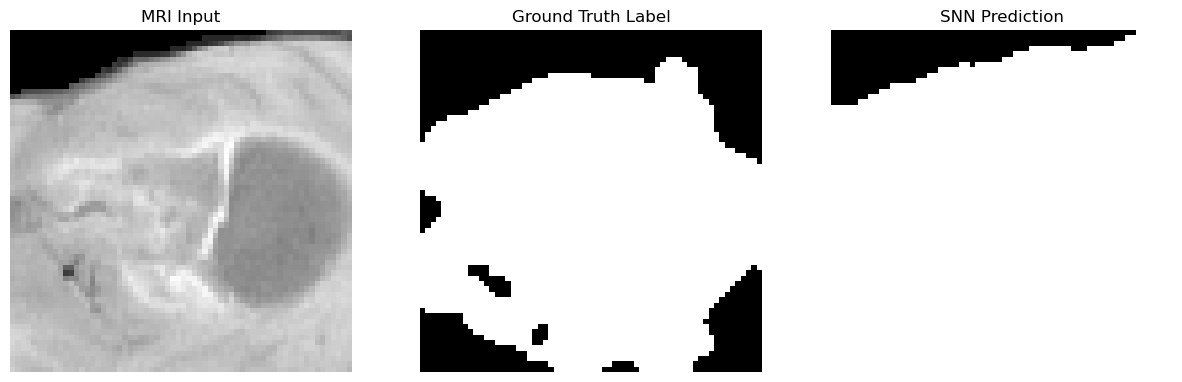

In [36]:
def visualize_results(model, loader, device, spike_len=8, slice_index=32):
    model.eval()
    
    # 1. Get a single batch
    batch = next(iter(loader))
    data = batch['mri'][tio.DATA].to(device)
    target = batch['seg'][tio.DATA].to(device).squeeze(1) # Remove channel dim
    target[target > 0] = 1
    target = target.squeeze(1)
    
    # 2. Run Inference
    spike_data = spikegen.rate(data, num_steps=spike_len)
    model.init_mem()
    
    mem_rec = []
    with torch.no_grad():
        for step in range(spike_len):
            _, mem_out = model(spike_data[step])
            mem_rec.append(mem_out)
    
    # 3. Process Output
    # Average over time -> (Batch, 2, D, H, W)
    final_logits = torch.stack(mem_rec).mean(dim=0)
    # Argmax to get class indices (0 or 1) -> (Batch, D, H, W)
    prediction = final_logits.argmax(dim=1)
    
    # 4. Plotting
    # We'll plot the first image in the batch
    img_idx = 0
    
    # Move to CPU for plotting
    mri_slice = data[img_idx, 0, :, :, slice_index].cpu().numpy()
    gt_slice = target[img_idx, :, :, slice_index].cpu().numpy()
    pred_slice = prediction[img_idx, :, :, slice_index].cpu().numpy()
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # MRI Image
    axes[0].imshow(mri_slice, cmap='gray')
    axes[0].set_title("MRI Input")
    axes[0].axis('off')
    
    # Ground Truth
    axes[1].imshow(gt_slice, cmap='gray')
    axes[1].set_title("Ground Truth Label")
    axes[1].axis('off')
     
    # Prediction
    axes[2].imshow(pred_slice, cmap='gray')
    axes[2].set_title("SNN Prediction")
    axes[2].axis('off')
    
    plt.show()

# --- Run the visualization ---
# slice_index=32 picks the middle slice of a 64x64x64 patch
visualize_results(model, val_loader, device, spike_len=spike_len, slice_index=32)

Eval: 100%|██████████| 408/408 [00:26<00:00, 15.27it/s]



Dice score: 0.5259
Mean Dice: 0.5259


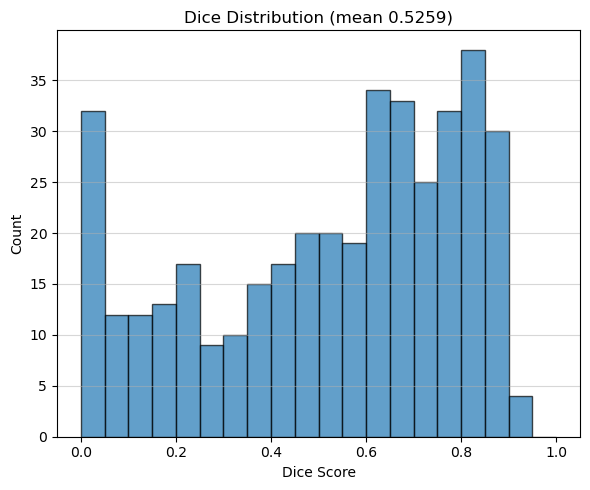

In [37]:
mean_dice, all_scores, best_sample = evaluate(model, val_loader, device, spike_len=spike_len)

print(f"Mean Dice: {mean_dice:.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.hist(all_scores, bins=20, range=(0, 1), edgecolor='black', alpha=0.7)
ax.set(xlabel='Dice Score', ylabel='Count', title=f'Dice Distribution (mean {mean_dice:.4f})')
ax.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()

In [38]:
def visualize_best_sample(best_sample, slice_index=32):
    if best_sample is None:
        print("No best sample captured during evaluation.")
        return

    mri_slice = best_sample["mri"][:, :, slice_index].numpy()
    gt_slice = best_sample["gt"][:, :, slice_index].numpy()
    pred_slice = best_sample["pred"][:, :, slice_index].numpy()

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(mri_slice, cmap="gray")
    axes[0].set_title("MRI Input")
    axes[0].axis("off")

    axes[1].imshow(gt_slice, cmap="gray")
    axes[1].set_title("Ground Truth Label")
    axes[1].axis("off")

    axes[2].imshow(pred_slice, cmap="gray")
    axes[2].set_title(f"SNN Prediction (Dice {best_sample['dice']:.4f})")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

Eval: 100%|██████████| 408/408 [00:27<00:00, 14.98it/s]



Dice score: 0.5292
Best Dice (distribution): 0.9478 (sample 348)


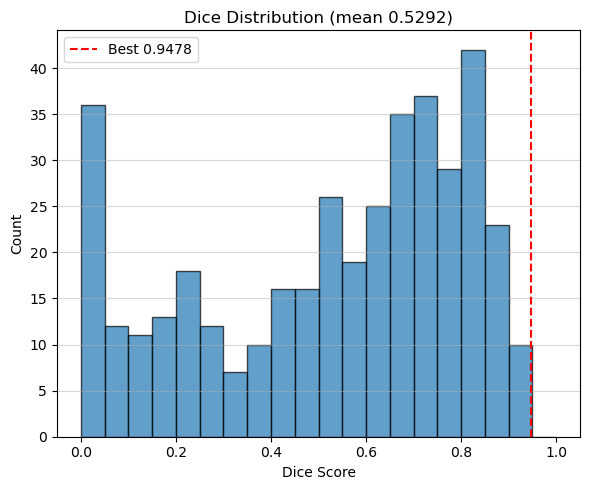

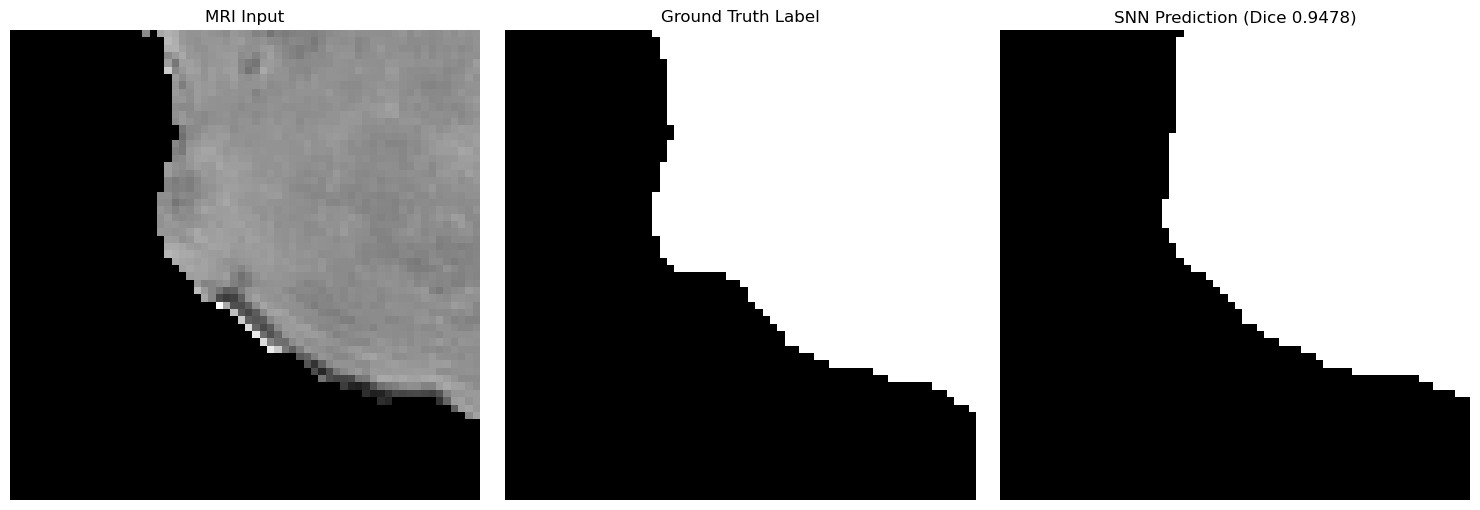

In [39]:
metrics = evaluate(model, val_loader, device, spike_len=spike_len)

mean_dice, all_scores, best_sample = metrics
best_idx = int(np.argmax(all_scores))
best_score = all_scores[best_idx]
print(f"Best Dice (distribution): {best_score:.4f} (sample {best_idx})")

fig, ax = plt.subplots(figsize=(6, 5))
ax.hist(all_scores, bins=20, range=(0, 1), edgecolor='black', alpha=0.7)
ax.axvline(best_score, color='red', linestyle='--', label=f'Best {best_score:.4f}')
ax.set(xlabel='Dice Score', ylabel='Count', title=f'Dice Distribution (mean {mean_dice:.4f})')
ax.grid(axis='y', alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()

visualize_best_sample(best_sample, slice_index=32)

In [31]:
def inspect_val_predictions_napari_low_dice(
    model, loader, device, spike_len=8, num_samples=3, dice_threshold=0.3
):
    model.eval()
    viewer = napari.Viewer(ndisplay=3)
    shown = 0
    eps = 1e-8

    with torch.no_grad():
        for batch in loader:
            data = batch["mri"][tio.DATA].to(device)
            targets = batch["seg"][tio.DATA].to(device).long()
            targets[targets > 0] = 1

            spike_data = spikegen.rate(data, num_steps=spike_len)
            model.init_mem()
            mem_rec = []
            for step in range(spike_len):
                _, mem_out = model(spike_data[step])
                mem_rec.append(mem_out)

            logits = torch.stack(mem_rec).mean(dim=0)
            preds = logits.argmax(dim=1)  # (B, D, H, W)

            b = data.shape[0]
            for i in range(b):
                gt = targets[i, 0]          # (D, H, W)
                pred = preds[i]             # (D, H, W)

                inter = (pred & gt).sum().float()
                denom = pred.sum().float() + gt.sum().float()
                dice = (2 * inter + eps) / (denom + eps)

                dice_val = float(dice.item())
                if dice_val < dice_threshold:
                    mri = data[i, 0].cpu().numpy()
                    gt_np = gt.cpu().numpy()
                    pred_np = pred.cpu().numpy()

                    viewer.add_image(
                        mri,
                        name=f"mri_dice_{dice_val:.3f}",
                        contrast_limits=(mri.min(), mri.max()),
                    )
                    viewer.add_labels(
                        gt_np,
                        name=f"gt_dice_{dice_val:.3f}",
                        opacity=0.4,
                    )
                    viewer.add_labels(
                        pred_np,
                        name=f"pred_dice_{dice_val:.3f}",
                        opacity=0.4,
                    )

                    shown += 1
                    if shown >= num_samples:
                        napari.run()
                        return

# Run
inspect_val_predictions_napari_low_dice(
    model, val_loader, device, spike_len=spike_len, num_samples=5, dice_threshold=0.1
)

Loaded checkpoint from epoch 5
Best Dice from training: 0.5309


Eval: 100%|██████████| 408/408 [00:27<00:00, 14.97it/s]



Dice score: 0.5328

Evaluation Results:
Mean Dice: 0.5328
Min Dice: 0.0000
Max Dice: 0.9264


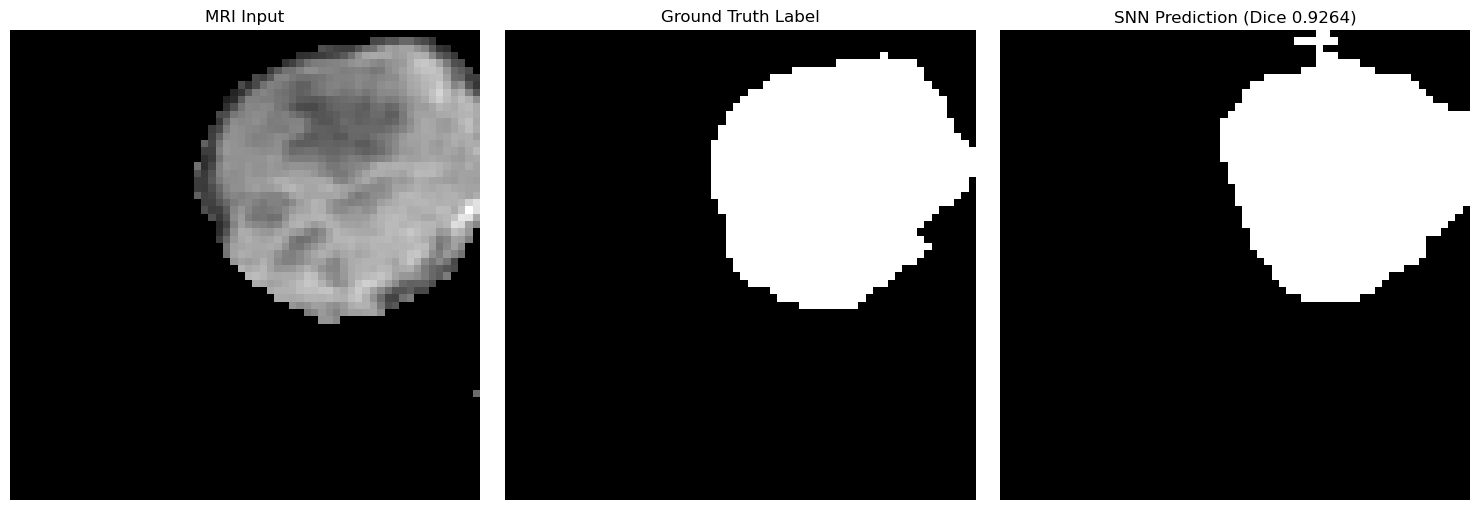

In [ ]:
# Load model from checkpoint and evaluate
ckpt_path = Path("checkpoints/spiking_unet_best.pt")

if not ckpt_path.exists():
    print(f"Checkpoint not found at {ckpt_path}")
else:
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = SpikingUnet(in_channels=1, out_chanels=2).to(device)
    checkpoint = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(checkpoint['model_state'])
    
    print(f"Loaded checkpoint from epoch {checkpoint['epoch']}")
    print(f"Best Dice from training: {checkpoint['best_dice']:.4f}")
    
    if 'val_loader' not in locals():
        train_queue, val_queue = build_patches(subjects)
        val_loader = DataLoader(val_queue, batch_size=1)
    

    spike_len = 8
    mean_dice, all_scores, best_sample = evaluate(model, val_loader, device, spike_len=spike_len)
    
    print(f"\nEvaluation Results:")
    print(f"Mean Dice: {mean_dice:.4f}")
    print(f"Min Dice: {min(all_scores):.4f}")
    print(f"Max Dice: {max(all_scores):.4f}")
    
    
    if best_sample is not None:
        visualize_best_sample(best_sample, slice_index=32)

In [33]:
# Count samples with no tumor voxels in ground truth
def count_empty_gt_samples(loader, num_samples=None):
    """
    Count how many samples have ground truth with no tumor voxels.
    
    Args:
        loader: DataLoader for the dataset
        num_samples: Number of samples to check (None = all samples)
    
    Returns:
        Dictionary with counts and percentages
    """
    empty_count = 0
    non_empty_count = 0
    total_count = 0
    
    print("Checking ground truth masks for tumor voxels...")
    
    for batch in tqdm(loader, desc="Checking GT masks", total=num_samples):
        targets = batch['seg'][tio.DATA]
        
        # Check each sample in batch
        for i in range(targets.shape[0]):
            gt_mask = targets[i, 0]  # Get the mask
            tumor_voxels = (gt_mask > 0).sum().item()
            
            if tumor_voxels == 0:
                empty_count += 1
            else:
                non_empty_count += 1
            
            total_count += 1
            
            if num_samples is not None and total_count >= num_samples:
                break
        
        if num_samples is not None and total_count >= num_samples:
            break
    
    results = {
        "total_samples": total_count,
        "empty_gt": empty_count,
        "non_empty_gt": non_empty_count,
        "empty_percentage": (empty_count / total_count * 100) if total_count > 0 else 0,
        "non_empty_percentage": (non_empty_count / total_count * 100) if total_count > 0 else 0
    }
    
    return results

# Run the check on validation loader
# Check first 300 samples (or all if you want)
results = count_empty_gt_samples(val_loader, num_samples=None)

print(f"\n{'='*50}")
print(f"Ground Truth Tumor Analysis")
print(f"{'='*50}")
print(f"Total samples checked: {results['total_samples']}")
print(f"Samples with NO tumor voxels: {results['empty_gt']} ({results['empty_percentage']:.2f}%)")
print(f"Samples with tumor voxels: {results['non_empty_gt']} ({results['non_empty_percentage']:.2f}%)")
print(f"{'='*50}")

Checking ground truth masks for tumor voxels...


Checking GT masks: 100%|██████████| 408/408 [00:07<00:00, 58.22it/s]


Ground Truth Tumor Analysis
Total samples checked: 408
Samples with NO tumor voxels: 13 (3.19%)
Samples with tumor voxels: 395 (96.81%)
